In [3]:
import numpy as np
import librosa
import librosa.display
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import sounddevice as sd
import ipywidgets as widgets
from IPython.display import display

In [14]:
def load_data(data_path):
    X = []
    y = []
    for folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, folder)
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            emotion = folder  # assuming folder name is the emotion label
            y.append(emotion)
            
            # Load the audio file
            audio, sr = librosa.load(file_path, sr=None)
            
            # Extract MFCC features
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
            mfcc = np.mean(mfcc.T, axis=0)
            X.append(mfcc)
    
    return np.array(X), np.array(y)

# Example: Provide the path to your dataset
data_path = "C:\\Users\\HP\\Documents\\ravdess data"
X, y = load_data(data_path)

In [3]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

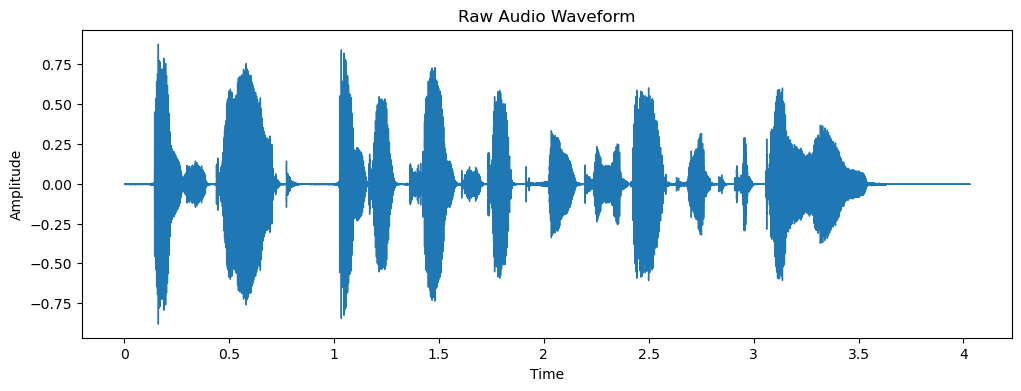

Button(description='Play Audio', style=ButtonStyle())

In [11]:
def load_raw_audio(audio_path):
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=None)
    return audio, sr

def plot_audio(audio, sr):
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(audio, sr=sr)
    plt.title('Raw Audio Waveform')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.show()

def play_audio(audio, sr):
    sd.play(audio, sr)
    sd.wait()  # Wait until the audio finishes playing

# Example usage:
audio_path = "C:\\Users\\HP\\Documents\\ravdess data\\sad emotion\\child_12.wav"  # Replace with your audio file path
audio, sr = load_raw_audio(audio_path)

# Plot the audio
plot_audio(audio, sr)

# Create a button to play audio
play_button = widgets.Button(description="Play Audio")

def on_play_button_clicked(b):
    play_audio(audio, sr)

# Link the button click event to the play audio function
play_button.on_click(on_play_button_clicked)

# Display the button
display(play_button)

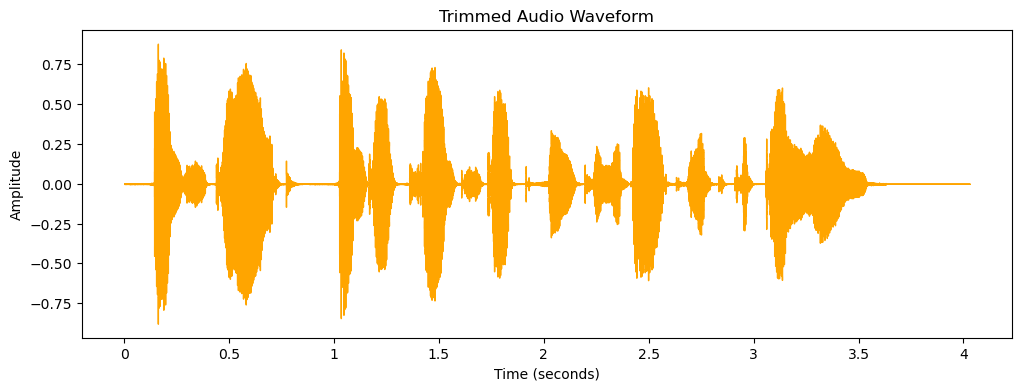

In [14]:
def load_raw_audio(audio_path):
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=None)
    return audio, sr

def plot_audio(audio, sr, title='Audio Waveform', color='b'):
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(audio, sr=sr, color=color)
    plt.title(title)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.show()

def trim_to_interval(audio_path, start_sec=0, end_sec=10):
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=None)
    
    # Convert seconds to samples
    start_sample = int(start_sec * sr)
    end_sample = int(end_sec * sr)
    
    # Trim the audio to the specified interval
    trimmed_audio = audio[start_sample:end_sample]
    
    return trimmed_audio, sr

# Example usage:
audio_path = "C:\\Users\\HP\\Documents\\ravdess data\\sad emotion\\child_12.wav"  # Replace with your audio file path
start_time = 0  # Start at the beginning
end_time = 10   # End at 10 seconds
trimmed_audio, sr = trim_to_interval(audio_path, start_time, end_time)

# Visualize the trimmed audio
plot_audio(trimmed_audio, sr, title='Trimmed Audio Waveform', color='orange')

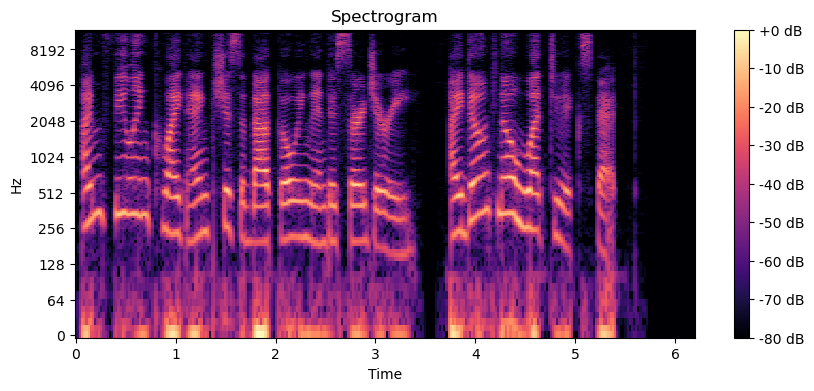

In [38]:
def generate_spectrogram(audio_path):
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=None)
    
    # Generate the spectrogram
    stft = np.abs(librosa.stft(audio))
    
    # Convert the spectrogram to decibels
    spectrogram = librosa.amplitude_to_db(stft, ref=np.max)
    
    return spectrogram, sr

# Example usage:
audio_path = "C:\\Users\\HP\\Documents\\ravdess data\\anxity emtion\\child_06.wav"  # Replace with your audio file path
spectrogram, sr = generate_spectrogram(audio_path)

# Display the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()


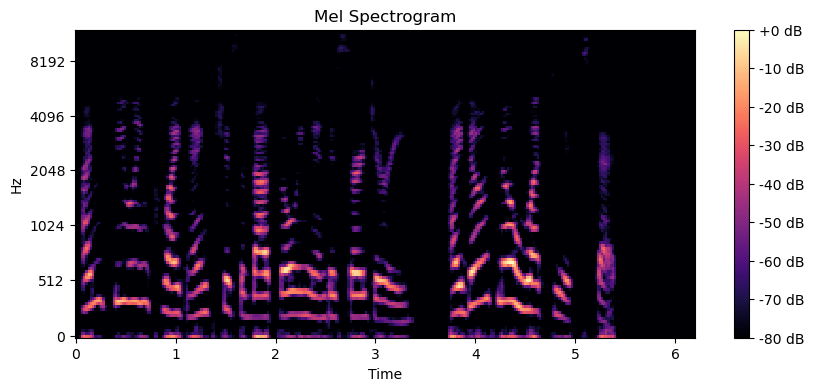

In [8]:
def generate_mel_spectrogram(audio_path, n_mels=128):
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=None)
    
    # Generate the mel spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    
    # Convert the mel spectrogram to decibels
    mel_spectrogram_db = librosa.amplitude_to_db(mel_spectrogram, ref=np.max)
    
    return mel_spectrogram_db, sr

# Example usage:
mel_spectrogram, sr = generate_mel_spectrogram(audio_path)

# Display the mel spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectrogram, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Flatten, Dropout, Input

# Define the model
model = Sequential()

# Input Layer (Explicitly define the input shape)
model.add(Input(shape=(X_train.shape[1], 1)))

# CNN Layer
model.add(Conv1D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# LSTM Layer
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))

# Fully Connected Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(y_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,653 (420.52 KB)

 Trainable params: 107,653 (420.52 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X_train, y_train, epochs=70, batch_size=32, validation_split=0.2)

Epoch 1/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3333 - loss: 1.7325 - val_accuracy: 0.3333 - val_loss: 1.5607
Epoch 2/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.1667 - loss: 1.6673 - val_accuracy: 0.0000e+00 - val_loss: 1.6546
Epoch 3/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4167 - loss: 1.5681 - val_accuracy: 0.0000e+00 - val_loss: 1.7277
Epoch 4/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1667 - loss: 1.6660 - val_accuracy: 0.0000e+00 - val_loss: 1.7510
Epoch 5/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2500 - loss: 1.5865 - val_accuracy: 0.0000e+00 - val_loss: 1.7350
Epoch 6/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3333 - loss: 1.4748 - val_accuracy: 0.0000e+00 - val_loss: 1.7113
Epoch 7/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3333 - loss: 1.4830 - val_accuracy: 0.0000e+00 - val_loss: 1.6976
Epoch 8/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3333 - loss: 1.4358 - val_accuracy: 

Epoch 51/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4167 - loss: 1.3469 - val_accuracy: 0.0000e+00 - val_loss: 2.6359
Epoch 52/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 1.1921 - val_accuracy: 0.0000e+00 - val_loss: 2.6971
Epoch 53/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4167 - loss: 1.2213 - val_accuracy: 0.0000e+00 - val_loss: 2.7212
Epoch 54/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5000 - loss: 1.1573 - val_accuracy: 0.0000e+00 - val_loss: 2.7600
Epoch 55/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5833 - loss: 1.1908 - val_accuracy: 0.0000e+00 - val_loss: 2.7456
Epoch 56/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6667 - loss: 0.9700 - val_accuracy: 0.0000e+00 - val_loss: 2.7298
Epoch 57/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5833 - loss: 1.2413 - val_accuracy: 0.0000e+00 - val_loss: 2.6703
Epoch 58/70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5000 - loss: 1.0267 - v

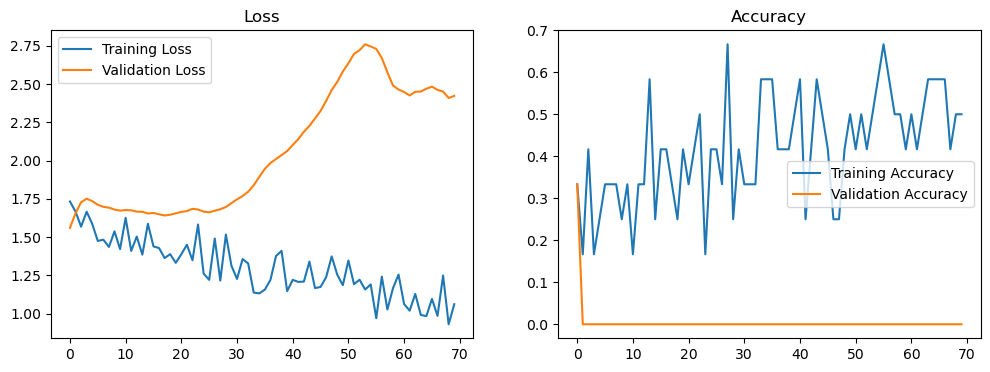

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()


In [35]:
def predict_emotion(audio_path):
    audio, sr = librosa.load(audio_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)
    mfcc = np.expand_dims(mfcc, axis=0)
    mfcc = np.expand_dims(mfcc, axis=-1)
    
    prediction = model.predict(mfcc)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
    
    return predicted_label[0]

# Example: Test with a new audio file
new_audio_path = "C:\\Users\\HP\\Documents\\ravdess data\\Neutral emotion\\child_5.wav"
predicted_emotion = predict_emotion(new_audio_path)
print(f'Predicted Emotion: {predicted_emotion}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Emotion: Neutral emotion
